<a href="https://colab.research.google.com/github/kiwi8803/Biometric/blob/main/Assign2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### If you are using Google Colab, you need to upload this notebook and the codebase to your Google Drive. Then you need to mount your Google Drive in Colab and set your working directory. If you are running on your local machine, you can ignore the following line.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os
root_dir = "/content/drive/My Drive/"
project_dir = "CS5332_Assign2/" # Change to your path
os.chdir(root_dir + project_dir)

In [31]:
# Make sure the path is correct
!ls

dataset			partII_assigment2.pdf  resnet18.pth
facenet-simplified.pdf	__pycache__	       utilities.py


## Important Functions

We need to define several important functions to facilitate our investigation:
* compute_face_features(test_dataset_path, model, num_classes=10)
* enroll(model, enroll_dataset_path="test_set/enroll_set")
* classify(template_by_id, embedding_by_id)

Please see the documentation for each function below.

In [32]:
# import necessary libraries/dependencies
import os
import numpy as np
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix
from utilities import *
import seaborn as sns

# define important helper functions
def compute_face_features(test_dataset_path, model, num_classes=10):
  """
  Computes face embeddings for images in the given dataset using a trained model.

  Parameters:
  - test_dataset_path (str): Path to the dataset containing test images.
  - model (torch.nn.Module): Pre-trained deep learning model for feature extraction.
  - num_classes (int, optional): Number of classes in the dataset. Default is 10.

  Returns:
  - dict: A dictionary where keys are identity labels and values are lists of computed embeddings.
  """

  test_dataset = CustomImageDataset(test_dataset_path, num_classes=num_classes, train=False)
  test_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=False) # batch_size must be 1 here
  model.to(device)
  embedding_by_id = load_face_embeddings(test_dataloader, model, device)

  return embedding_by_id

def enroll(model, enroll_dataset_path="test_set/enroll_set"):
  """
  Generates face templates by computing the average embedding for each identity in the dataset.

  Parameters:
  - model (torch.nn.Module): Pre-trained deep learning model for feature extraction.
  - enroll_dataset_path (str, optional): Path to the enrollment dataset. Default is "test_set/enroll_set".

  Returns:
  - dict: A dictionary where keys are identity labels and values are their average face embeddings.
  """


  embedding_by_id = compute_face_features(enroll_dataset_path, model)
  template_by_id = {}
  for idx in list(set(embedding_by_id.keys())):
    # ---- Fill in your code here ---- #
    identity_embeddings = np.array(embedding_by_id[idx])
    template_by_id[idx] = np.mean(identity_embeddings, axis=0)

  return template_by_id

def classify(template_by_id, embedding_by_id):
  """
  Classifies face embeddings by comparing them to precomputed templates and assigns labels.
  Note: this implements the 1-NN classification.

  Parameters:
  - template_by_id (dict): Dictionary containing identity labels as keys and their corresponding template embeddings.
  - embedding_by_id (dict): Dictionary containing identity labels as keys and lists of face embeddings.

  Returns:
  - float: The classification accuracy.
  - np.ndarray: The confusion matrix representing classification performance.
  """

  true_labels = []
  predicted_labels = []

  # For each idx, we have several face images and corresponding face features
  # We want to compute their distances to each idx's template, and classify them
  # by finding the idx of the template yielding the smallest distance

  # ---- Fill in your code here ---- #
  # Iterate through each identity and their corresponding probe image embeddings.
  for true_id, probe_list in embedding_by_id.items():
      for probe_emb in probe_list:
          true_labels.append(true_id)

          # Implement 1-Nearest Neighbor search.
          min_dist = float('inf')
          best_id = None

          for template_id, template_emb in template_by_id.items():
              # Calculate the Euclidean distance (L2 norm) between the probe and template.
              dist = np.linalg.norm(probe_emb - template_emb)
              # identify the indentity with the smallest distance
              if dist < min_dist:
                  min_dist = dist
                  best_id = template_id

          predicted_labels.append(best_id)

  # we compute the accuracy and confusion matrix
  accuracy = accuracy_score(true_labels, predicted_labels)
  conf_matrix = confusion_matrix(true_labels, predicted_labels)

  return accuracy, conf_matrix

### It is important to define a device to load the model and dataset. Don't forget to run the following code.

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Part II.3 Pre-trained Features

Please study the following code carefully. You may reuse some of them for subsequent parts.

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 110MB/s]


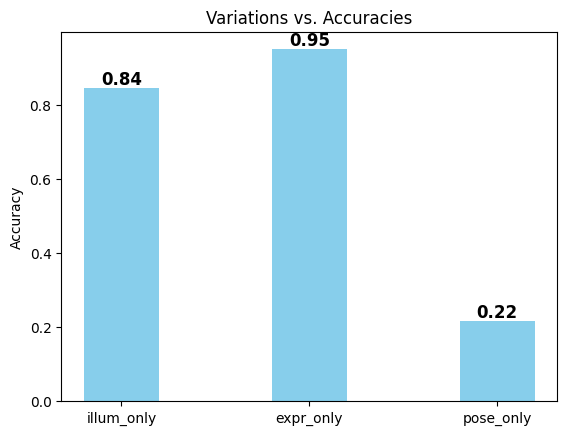

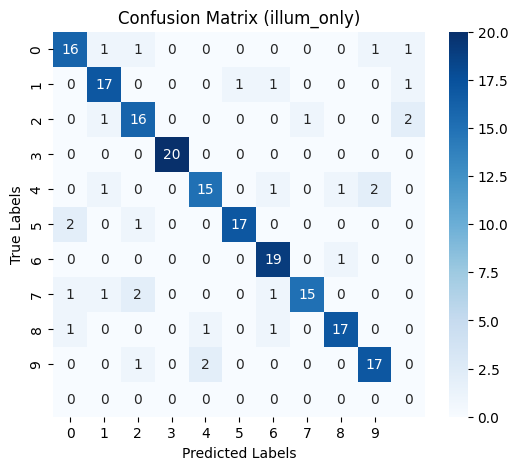

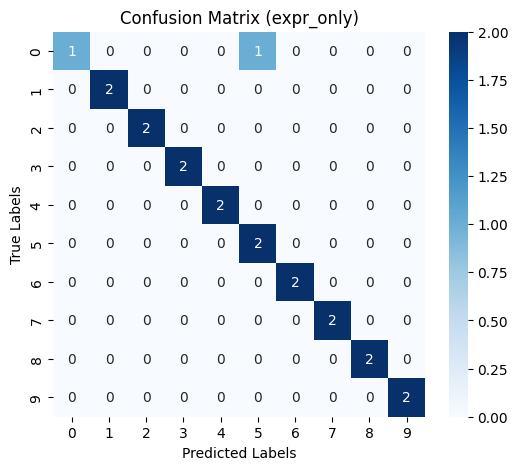

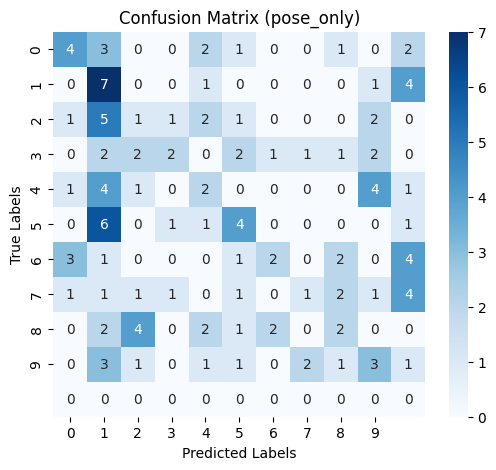


###
- The Accuracy of the FIS for probe using illum_only is 85%


In [6]:
# Load model
model = load_model(num_classes=10, include_fc=False) # we only have 10 people in the test dataset

# We do not need any training here
# Instead, we directly use the pre-trained ResNet-18 to do classification

# We first enroll using our test dataset test_set/enroll to obtain the templates for each person
template_by_id = enroll(model, enroll_dataset_path="test_set/enroll_set")

# We then compute the face features for each dataset
# Note we have three variations: illum_only, expr_only, pose_only
variations = ["illum_only", "expr_only", "pose_only"]
#variations = ["illum_only"]
accuracies = []
conf_matrices = []
for variation in variations:
  test_dataset_path = f"test_set/{variation}"
  embedding_by_id = compute_face_features(test_dataset_path, model)
  accuracy, conf_matrix = classify(template_by_id, embedding_by_id)
  accuracies.append(accuracy)
  conf_matrices.append(conf_matrix)

# Plot a bar plot
fig, ax = plt.subplots()
bars = ax.bar(variations, accuracies, width=0.4, color='skyblue')

# Add text labels above the bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.2f}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

# Customize plot
ax.set_ylabel('Accuracy')
ax.set_title('Variations vs. Accuracies')

plt.show()

# Show confusion matrix
for i, conf_matrix in enumerate(conf_matrices):
  plt.figure(figsize=(6, 5))
  sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=range(10), yticklabels=range(10))
  plt.xlabel("Predicted Labels")
  plt.ylabel("True Labels")
  plt.title(f"Confusion Matrix ({variations[i]})")
  plt.show()

from IPython.display import Markdown
display(Markdown(f"""
###
- The Accuracy of the FIS for probe using illum_only is 85%
"""))

## Part II.4 Illumination-invariant features

Please complete and run the following code

In [8]:
# Step 1: Load model
num_classes = 50 # you can change the value here
model = load_model(num_classes=num_classes, include_fc=True)
#Note utilities.py loads resnet18 with pretrained if weight is None

# Step 2: Load dataset
batch_size = 4 # you can change the value here
training_dataset = CustomImageDataset("illum_train", num_classes=num_classes, train=True) # we wll train using the illum_train dataset
training_dataloader = DataLoader(training_dataset, batch_size=batch_size, shuffle=True)

(Optional) Visualize images in the training_dataloader

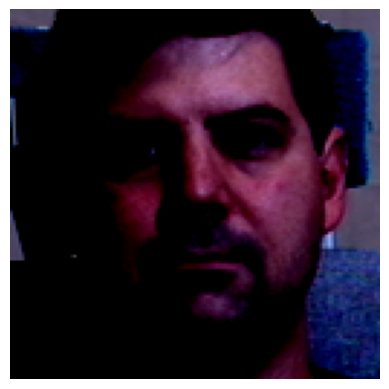

<Figure size 500x500 with 0 Axes>

In [9]:
# Get a batch of images
data_iter = iter(training_dataloader)
images, labels = next(data_iter)

# Convert from tensor to numpy
batch_index = 0 # change to visualize a different image in the batch
img = images[batch_index].numpy().transpose((1, 2, 0))
plt.imshow(img)
plt.axis("off")

# Show the image
plt.figure(figsize=(5, 5))
plt.show()

In [10]:
# Step 3: Train the model

# Register model to CPU or GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# You can change the following hyperparameters for training
num_epochs = 5
learning_rate = 1e-3
model_path = "resnet18.pth"

# Train the model
train(model, training_dataloader, device, save_path=model_path, num_epochs=num_epochs, learning_rate=learning_rate)

Epoch [1/5], Loss: 1.4326
Epoch [2/5], Loss: 0.1049
Epoch [3/5], Loss: 0.1464
Epoch [4/5], Loss: 0.1094
Epoch [5/5], Loss: 0.0742
Model saved to resnet18.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


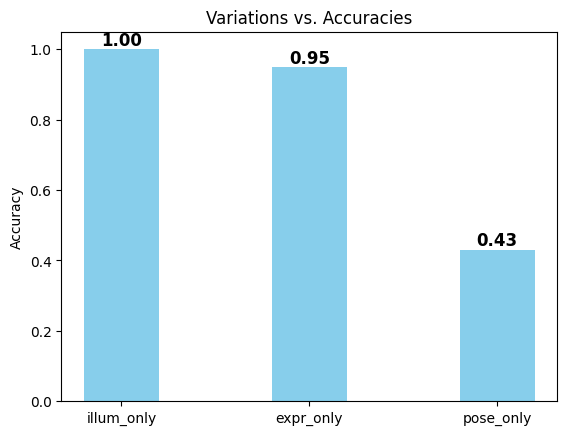

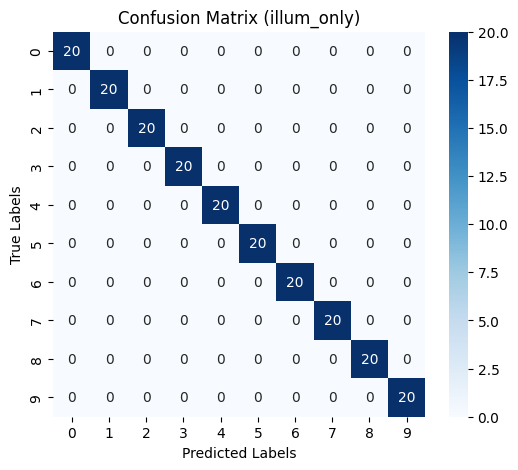

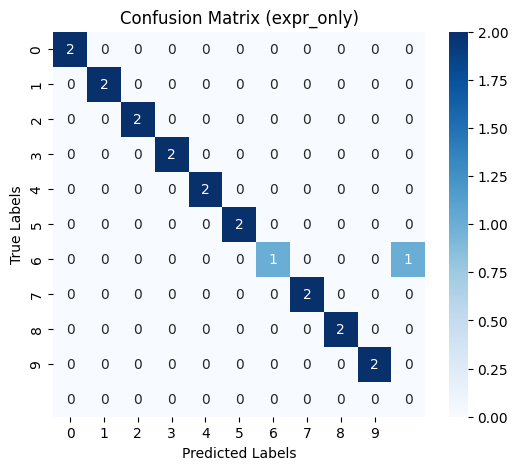

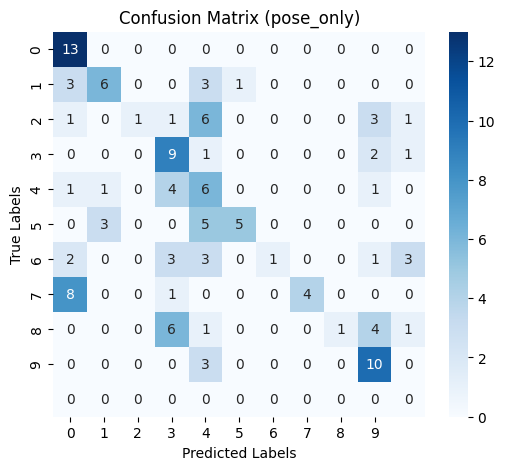


###
- given that the illum_train data consist of 50 people(Classes) x 20 illumination(Variation)
- we used 50 (N) classes for fine-tuning utilizes the full distribution of the training population to find features with minimal intra-class varaition and maximal inter-class variation
- This approach optimizes the classifer by forcing the model to find the most discriminative features to keep all N cluster distinct. resulting in improvment in accuracy from 85%
- However, although this system is now illumination-invariant, we note that it doesnt perform well against expression and pose variation, infact pose variation drop from 95% to 90% as compared to standard ResNet=18 accuracy


In [11]:
# You can change the following for different variations
test_dataset_path = "test_set/illum_only"
trained_model_path = "resnet18.pth"

# We need to load the model again for testing
# Fix: Load the model with include_fc=True to match the saved state_dict,
# then manually replace the FC layer for feature extraction.
import torch.nn as nn # Ensure nn is imported for nn.Identity

model = load_model(num_classes=num_classes, weights=trained_model_path)
model.eval()

# Now write your own code to do classification and report accuracy for each variation

# ---- Fill in your code here ---- #

# We first enroll using our test dataset test_set/enroll to obtain the templates for each person
template_by_id = enroll(model, enroll_dataset_path="test_set/enroll_set")

# We then compute the face features for each dataset
# Note we have three variations: illum_only, expr_only, pose_only
variations = ["illum_only", "expr_only", "pose_only"]
accuracies = []
conf_matrices = []
for variation in variations:
  test_dataset_path = f"test_set/{variation}"
  embedding_by_id = compute_face_features(test_dataset_path, model)
  accuracy, conf_matrix = classify(template_by_id, embedding_by_id)
  accuracies.append(accuracy)
  conf_matrices.append(conf_matrix)

# Plot a bar plot
fig, ax = plt.subplots()
bars = ax.bar(variations, accuracies, width=0.4, color='skyblue')

# Add text labels above the bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.2f}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

# Customize plot
ax.set_ylabel('Accuracy')
ax.set_title('Variations vs. Accuracies')

plt.show()

# Show confusion matrix
for i, conf_matrix in enumerate(conf_matrices):
  plt.figure(figsize=(6, 5))
  sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=range(10), yticklabels=range(10))
  plt.xlabel("Predicted Labels")
  plt.ylabel("True Labels")
  plt.title(f"Confusion Matrix ({variations[i]})")
  plt.show()

from IPython.display import Markdown
display(Markdown(f"""
###
- given that the illum_train data consist of 50 people(Classes) x 20 illumination(Variation)
- we used 50 (N) classes for fine-tuning utilizes the full distribution of the training population to find features with minimal intra-class varaition and maximal inter-class variation
- This approach optimizes the classifer by forcing the model to find the most discriminative features to keep all N cluster distinct. resulting in improvment in accuracy from 85%
- However, although this system is now illumination-invariant, we note that it doesnt perform well against expression and pose variation, infact pose variation drop from 95% to 90% as compared to standard ResNet=18 accuracy
"""))

## Part II.5 Illum- and pose-invariant features

Now we repeat the same process, but we change the training dataset to illum_train and pose_train.

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch [1/5], Loss: 1.8220
Epoch [2/5], Loss: 0.4956
Epoch [3/5], Loss: 0.2259
Epoch [4/5], Loss: 0.2416
Epoch [5/5], Loss: 0.1664
Model saved to resnet18.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


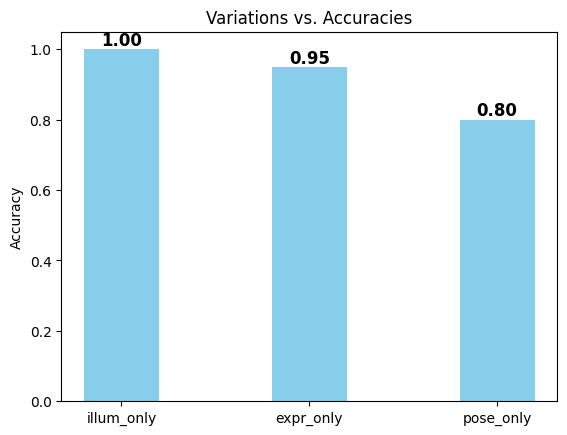

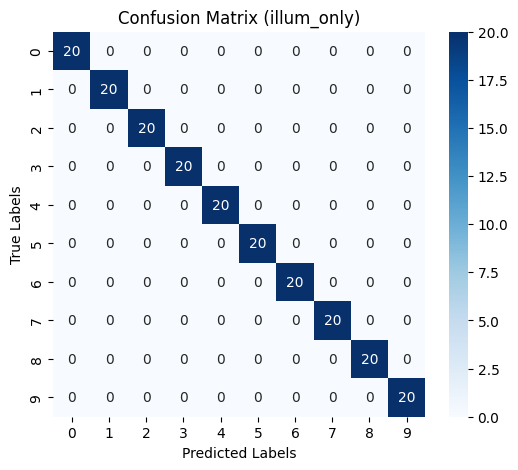

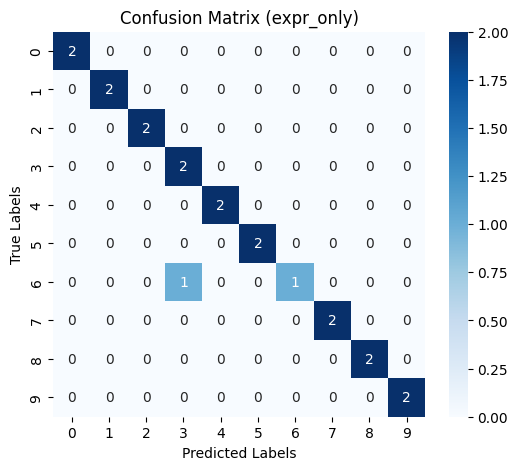

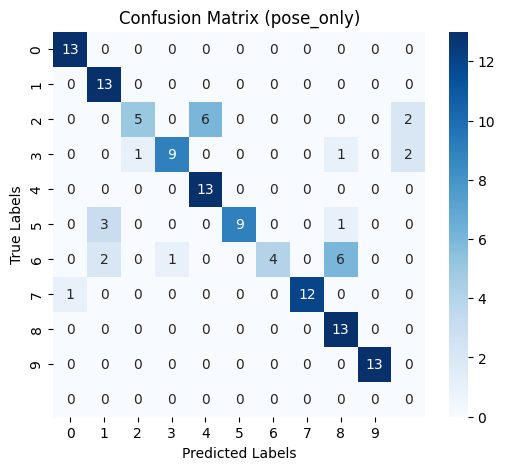


###
- Improvement of accuracy in pose variation was observed (from 36% to 73%)
- This is likely due to the pose training provided the feature extractor with necessary data to find features that are invariant to head orientation
- The classifer remained illumantion invariant, this is likely due to features required for illumination invariance and pose invariance are often statistically independent
  - illumination invariance oftem relies on local pixel intensity ratios
  - whereas pose invariance relies more on 3D gemetry and spatial relationship between points
  

In [12]:
# Step1: load model
num_classes = 50
model = load_model(num_classes=num_classes, include_fc=True)
model.to(device)

# Step2: load dataset (dataloader)

training_dataset = CustomImageDataset("illum_train+pose_train", num_classes=num_classes, train=True)
training_dataloader = DataLoader(training_dataset, batch_size=batch_size, shuffle=True)

# Step3: train model
# You can change the following hyperparameters for training
num_epochs = 5
learning_rate = 1e-3
model_path = "resnet18.pth"
batch_size = 4
train(model, training_dataloader, device, save_path=model_path, num_epochs=num_epochs, learning_rate=learning_rate)

# Now write your own code to do classification and report accuracy for each variation
# You also need to compute and show confusion matrix in this part
trained_model_path = "resnet18.pth"
model = load_model(num_classes=num_classes, weights=trained_model_path)
model.eval()

# We first enroll using our test dataset test_set/enroll to obtain the templates for each person
template_by_id = enroll(model, enroll_dataset_path="test_set/enroll_set")

# We then compute the face features for each dataset
# Note we have three variations: illum_only, expr_only, pose_only
variations = ["illum_only", "expr_only", "pose_only"]
accuracies = []
conf_matrices = []
for variation in variations:
  test_dataset_path = f"test_set/{variation}"
  embedding_by_id = compute_face_features(test_dataset_path, model)
  accuracy, conf_matrix = classify(template_by_id, embedding_by_id)
  accuracies.append(accuracy)
  conf_matrices.append(conf_matrix)

# Plot a bar plot
fig, ax = plt.subplots()
bars = ax.bar(variations, accuracies, width=0.4, color='skyblue')

# Add text labels above the bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.2f}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

# Customize plot
ax.set_ylabel('Accuracy')
ax.set_title('Variations vs. Accuracies')

plt.show()

# Show confusion matrix
for i, conf_matrix in enumerate(conf_matrices):
  plt.figure(figsize=(6, 5))
  sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=range(10), yticklabels=range(10))
  plt.xlabel("Predicted Labels")
  plt.ylabel("True Labels")
  plt.title(f"Confusion Matrix ({variations[i]})")
  plt.show()

from IPython.display import Markdown
display(Markdown(f"""
###
- Improvement of accuracy in pose variation was observed (from 36% to 73%)
- This is likely due to the pose training provided the feature extractor with necessary data to find features that are invariant to head orientation
- The classifer remained illumantion invariant, this is likely due to features required for illumination invariance and pose invariance are often statistically independent
  - illumination invariance oftem relies on local pixel intensity ratios
  - whereas pose invariance relies more on 3D gemetry and spatial relationship between points
  """))

Displaying Faces corresponding to specific misclassification in pose_only variation

In [13]:
# 1. Configuration: Set the indices identified from your Confusion Matrix
# Note: If the ID is '8', its numerical index in your label mapping might be different
# due to string sorting (e.g., '1', '10', '2'...). Check your label_to_index mapping.
target_true_label = 8  # Row index in confusion matrix
target_pred_label = 4  # Column index in confusion matrix

found_img_idx_in_dict = -1
# 1. Define the path to the pose test set
test_dataset_path = "test_set/pose_only"


test_dataset_pose = CustomImageDataset(test_dataset_path, num_classes=10, train=False)

embedding_by_id_pose = compute_face_features("test_set/pose_only", model)
# 2. Identify the specific misclassified probe index
# We look through the list of embeddings for the person who was misclassified
for i, probe_emb in enumerate(embedding_by_id_pose[target_true_label]):
    # Perform 1-NN matching manually to find the sample that hit the error
    distances = {label: np.linalg.norm(probe_emb - temp) for label, temp in template_by_id.items()}
    predicted_label = min(distances, key=distances.get)

    if predicted_label == target_pred_label:
        found_img_idx_in_dict = i
        print(f"Found misclassification: Sample {i} of Label {target_true_label} was predicted as {target_pred_label}")
        break

# 3. Retrieve the correct file paths from the dataset
if found_img_idx_in_dict != -1:
    # Find the i-th path belonging to the target person in the dataset's image list
    current_count = 0
    probe_path = None
    for path, label in zip(test_dataset_pose.imagepaths, test_dataset_pose.labels):
        if label == target_true_label:
            if current_count == found_img_idx_in_dict:
                probe_path = path
                break
            current_count += 1

    # Grab the first available template image for the predicted (wrong) identity
    template_path = None
    for path, label in zip(test_dataset_pose.imagepaths, test_dataset_pose.labels):
        if label == target_pred_label:
            template_path = path # In enrollment, this would be from the enroll set
            break

    # 4. Display the images side-by-side
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(Image.open(probe_path))
    plt.title(f"Probe (True: {target_true_label})\nPredicted: {target_pred_label}")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(Image.open(template_path))
    plt.title(f"Confused with Template:\nLabel {target_pred_label}")
    plt.axis('off')
    plt.show()

    # 5. Compute Euclidean distances for analysis
    # Distance to the wrong template vs distance to the correct template
    correct_temp = template_by_id[target_true_label]
    wrong_temp = template_by_id[target_pred_label]
    probe_emb = embedding_by_id_pose[target_true_label][found_img_idx_in_dict]

    print(f"Distance to Correct Identity: {np.linalg.norm(probe_emb - correct_temp):.4f}")
    print(f"Distance to Predicted Identity: {np.linalg.norm(probe_emb - wrong_temp):.4f}")
    display(Markdown(f"""
###
- sample 0 of label 8 indeed shares similar feature such as wearing spectacles and look similar.
- comparing the distance the distance to correct identity(21.7667) > distance(20.8220) to predicted identity.

- this is likely due to them
  - wearing similar glasses, which hides distinctive and precese shap and texture of regions such as eyes and are replaced by the geometry of the glasses.
  - another factor may be due to a similar hairstyle that might have influenced the general shape of the face
  """))

## Part II.6 FaceNet

[IMPORTANT!] The following code only needs to be excecuted once. You may need to restart the session after installation.

In [14]:
!pip cache purge
!pip install facenet-pytorch

Files removed: 0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 39.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 58.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 61.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 45.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

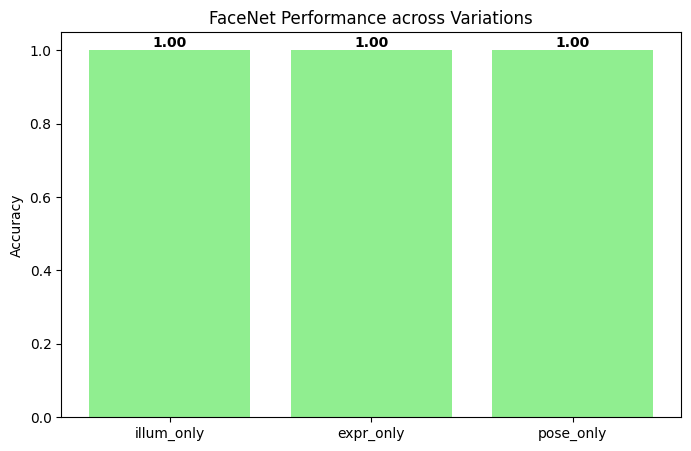

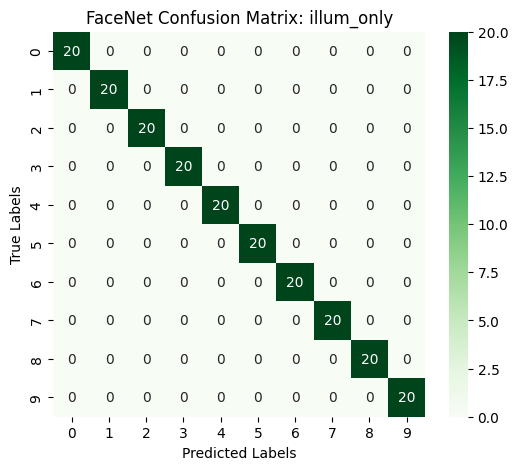

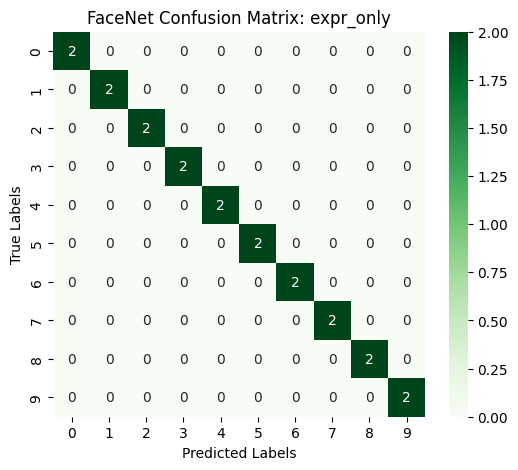

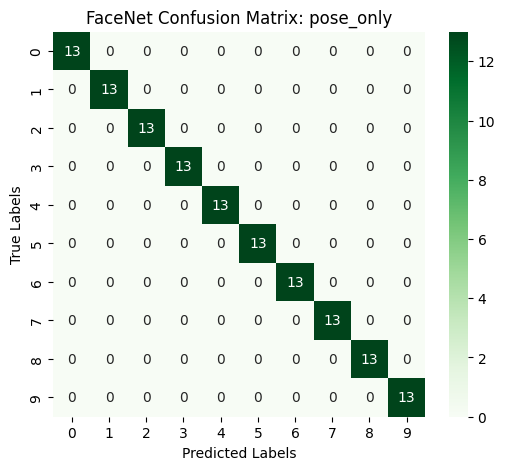

Using FaceNet we see marked improvement of 100% accuracy for all category


In [16]:
from facenet_pytorch import InceptionResnetV1
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os
import numpy as np # Already imported, but for clarity
from utilities import *

# Define the device for computation
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# We need to modify the helper functions
def compute_facenet_features(test_dataset_path, model):
  test_dataset = FaceNetImageDataset(test_dataset_path)
  test_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=False) # batch_size must be 1 here
  model.to(device)
  embedding_by_id = load_face_embeddings(test_dataloader, model, device)
  return embedding_by_id

def enroll_facenet(model, enroll_dataset_path="test_set/enroll_set"): # Updated default path
  embedding_by_id = compute_facenet_features(enroll_dataset_path, model)
  template_by_id = {}
  for idx in list(set(embedding_by_id.keys())):
    # ---- Fill in your code here ---- #
    template_by_id[idx] = np.mean(embedding_by_id[idx], axis=0)
  return template_by_id

# Load model
model = InceptionResnetV1(pretrained='vggface2').eval()

# Now write your own code to do classification and report accuracy for each variation

# ---- Fill in your code here ---- #

facenet_templates = enroll_facenet(model, enroll_dataset_path="test_set/enroll_set") # Updated call path

# Step 2: Evaluate on all 3 variations
variations = ["illum_only", "expr_only", "pose_only"]
facenet_accuracies = []
facenet_conf_matrices = []

for variation in variations:
    test_path = f"test_set/{variation}" # Updated path construction
    # Extract features for current variation
    facenet_embeddings = compute_facenet_features(test_path, model)

    if len(facenet_embeddings) == 0:
      print(f"Warning: No images found for variation '{variation}' at path: dataset/{test_path}")
      continue

    # Classify using the 1-NN (Euclidean distance) rule [2, 4]
    acc, cm = classify(facenet_templates, facenet_embeddings)
    facenet_accuracies.append(acc)
    facenet_conf_matrices.append(cm)

# --- Reporting Results ---

# 1. Bar Chart of Accuracies [3]
plt.figure(figsize=(8, 5))
plt.bar(variations, facenet_accuracies, color='lightgreen')
plt.ylabel('Accuracy')
plt.title('FaceNet Performance across Variations')
for i, acc in enumerate(facenet_accuracies):
    plt.text(i, acc + 0.01, f'{acc:.2f}', ha='center', fontweight='bold')
plt.show()

# 2. Confusion Matrices
for i, cm in enumerate(facenet_conf_matrices):
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.title(f"FaceNet Confusion Matrix: {variations[i]}")
    plt.show()

print("Using FaceNet we see marked improvement of 100% accuracy for all category")

Probing with images

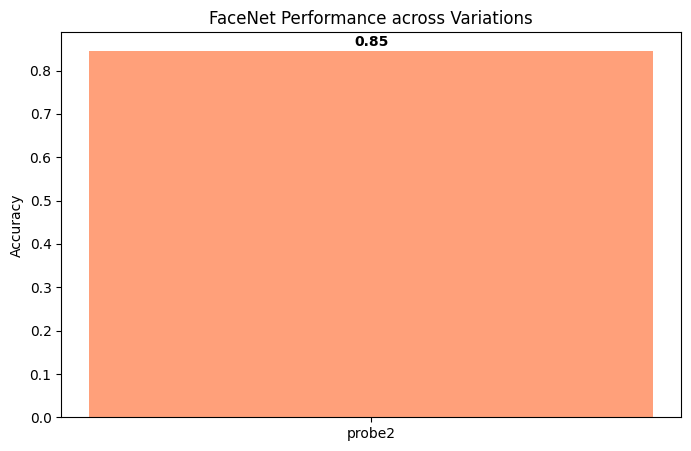

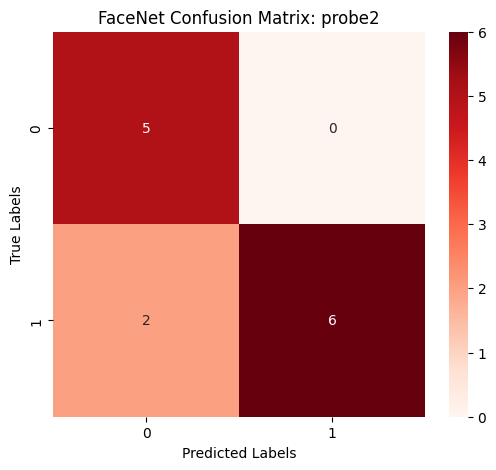

In [76]:
variations = ["probe2"]
facenet_accuracies = []
facenet_conf_matrices = []

# Storage for failure case details
failure_case = None

for variation in variations:
    test_path = f"test_set/{variation}" # Updated path construction
    # Extract features for current variation
    facenet_embeddings = compute_facenet_features(test_path, model)

    if len(facenet_embeddings) == 0:
      print(f"Warning: No images found for variation '{variation}' at path: dataset/{test_path}")
      continue

    # Classify using the 1-NN (Euclidean distance) rule [2, 4]
    acc, cm = classify(facenet_templates, facenet_embeddings)
    facenet_accuracies.append(acc)
    facenet_conf_matrices.append(cm)

# --- Reporting Results ---

# 1. Bar Chart of Accuracies [3]
plt.figure(figsize=(8, 5))
plt.bar(variations, facenet_accuracies, color='lightsalmon')
plt.ylabel('Accuracy')
plt.title('FaceNet Performance across Variations')
for i, acc in enumerate(facenet_accuracies):
    plt.text(i, acc + 0.01, f'{acc:.2f}', ha='center', fontweight='bold')
plt.show()

# 2. Confusion Matrices
for i, cm in enumerate(facenet_conf_matrices):
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Reds")
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.title(f"FaceNet Confusion Matrix: {variations[i]}")
    plt.show()


results above shows that the probe sucessfully fooled FaceNet. we want to find the image that resulted the misclassification to understand which factor caused this.( intra-class variation is larger than inter-class variation)

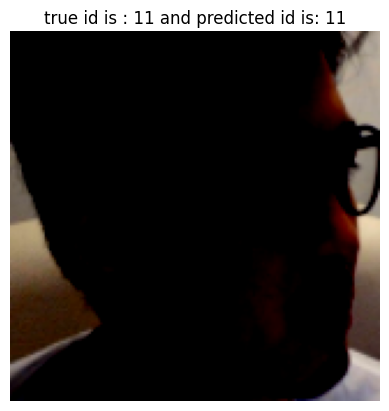

<Figure size 500x500 with 0 Axes>

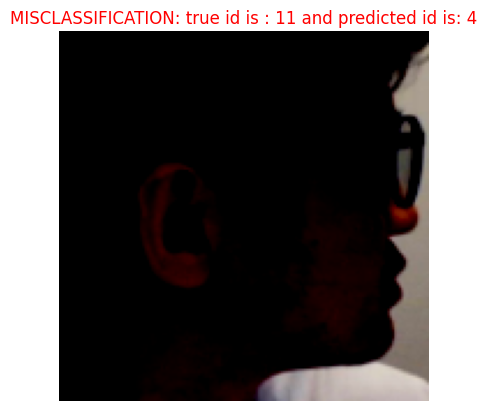

<Figure size 500x500 with 0 Axes>

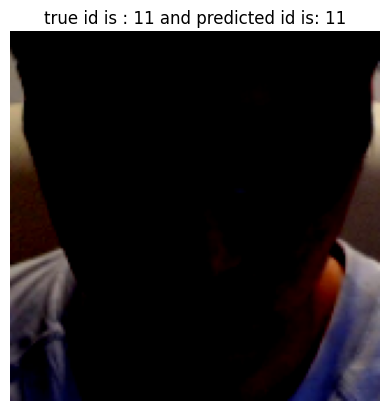

<Figure size 500x500 with 0 Axes>

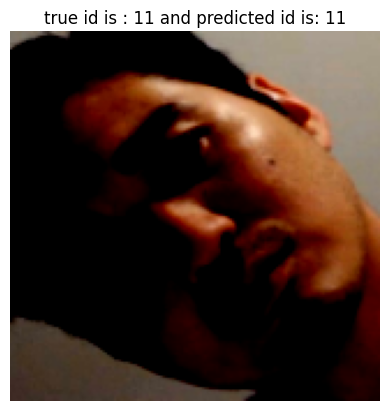

<Figure size 500x500 with 0 Axes>

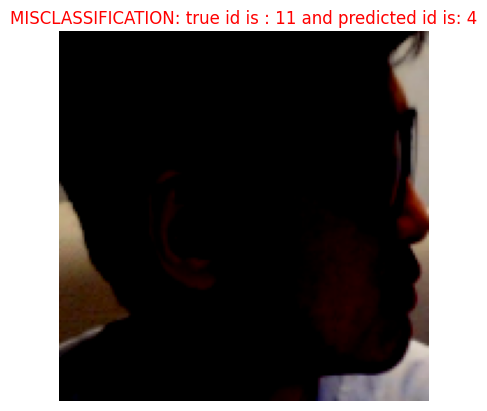

<Figure size 500x500 with 0 Axes>

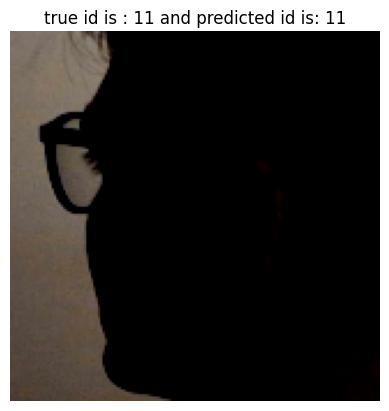

<Figure size 500x500 with 0 Axes>

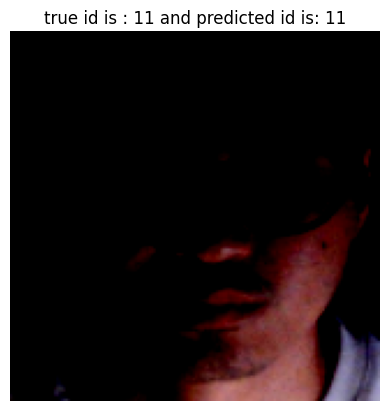

<Figure size 500x500 with 0 Axes>

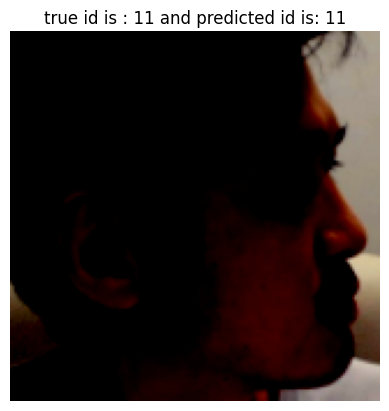

<Figure size 500x500 with 0 Axes>

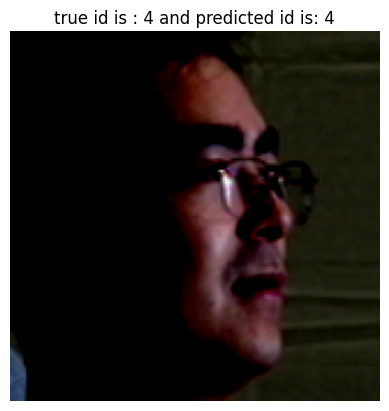

<Figure size 500x500 with 0 Axes>

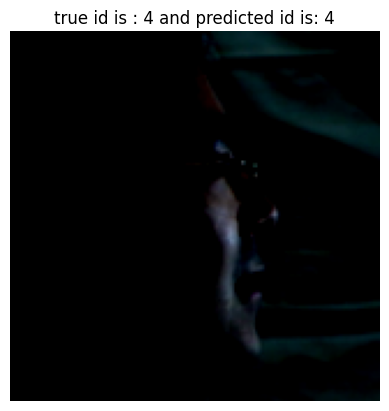

<Figure size 500x500 with 0 Axes>

In [77]:

true_labels = []
predicted_labels = []
idx =0
test_path = f"test_set/probe3"
probe_embeddings = compute_facenet_features(test_path, model)

test_dataset = FaceNetImageDataset(test_path)
test_dataloader = DataLoader(test_dataset, batch_size=20, shuffle=False)
data_iter = iter(test_dataloader)
images, labels = next(data_iter)

for true_id, probe_list in probe_embeddings.items():
    for probe_emb in probe_list:

        # Implement 1-Nearest Neighbor search.
        min_dist = float('inf')
        best_id = None

        for template_id, template_emb in facenet_templates.items():
            # Calculate the Euclidean distance (L2 norm) between the probe and template.
            dist = np.linalg.norm(probe_emb - template_emb)
              # identify the indentity with the smallest distance
            if dist < min_dist:
                min_dist = dist
                best_id = template_id
        true_labels.append(true_id)
        predicted_labels.append(best_id)
        batch_index = idx # change to visualize a different image in the batch
        if true_id != best_id:
          plt.title(f"MISCLASSIFICATION: true id is : {true_id} and predicted id is: {best_id}", color="red")
        else:
          plt.title(f"true id is : {true_id} and predicted id is: {best_id}")
        img = images[batch_index].numpy().transpose((1, 2, 0))
        plt.imshow(img)
        plt.axis("off")

        # Show the image
        plt.figure(figsize=(5, 5))
        plt.show()

        idx+=1




